📋 How to Run this Demo

Step 1: Environment Setup

Run the first code cell to install the required library: !pip install ultralytics

Step 2: Upload Files

Click the Folder icon (Files) on the left sidebar.

Upload your trained model file: best.pt.

Upload your test media file (Image .jpg or Video .mp4).

Step 3: Configuration

In the main code cell, update the source variable to match your uploaded filename:
source = "your_image.jpg"  # or "your_video.mp4"

Step 4: Execution & Results

Run the code cell.

For Images: The result will be displayed directly below the cell.

For Videos: The processed video will be saved in the ket_qua_output folder. Please download it to view the smooth playback.

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.6 MB/s eta 0:00:00


🚀 Đang load model: best.pt...
📂 Nguồn dữ liệu: IMG_4169-MOV_out0003_png.rf.4250a0069a62e1ddb8baab89bec02f9b.jpg (Loại: image)

0: 640x640 1 Curve Right, 46.5ms
Speed: 1.7ms preprocess, 46.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
✅ Đã lưu ảnh tại: ket_qua_output/result_IMG_4169-MOV_out0003_png.rf.4250a0069a62e1ddb8baab89bec02f9b.jpg.jpg
👇 Kết quả nhận diện:


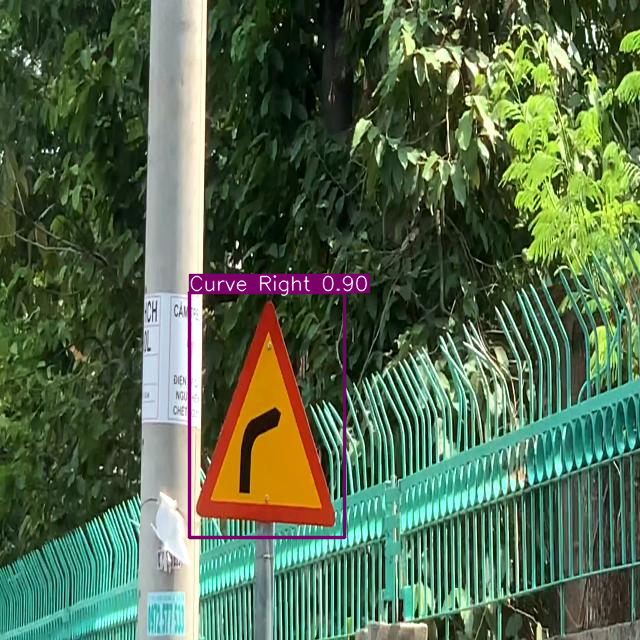

In [ ]:
import cv2
from ultralytics import YOLO
import os
import sys
# Colab-specific library for image display
from google.colab.patches import cv2_imshow

# --- CONFIGURATION -----
model_path = 'best.pt'
# CHANGE ONLY THIS LINE:
source = "IMG_4169-MOV_out0003_png.rf.4250a0069a62e1ddb8baab89bec02f9b.jpg"  # The image or video filename uploaded to Colab
output_folder = "ket_qua_output" # Output folder directory
# ------------------

# Create the output directory if it does not exist
os.makedirs(output_folder, exist_ok=True)

print(f"Loading model: {model_path}...")
try:
    model = YOLO(model_path)
except Exception as e:
    print(f"Error loading model: {e}")
    # Use sys.exit() on Colab to cleanly stop execution within the cell
    sys.exit()

# --- FILE TYPE VERIFICATION --- 
def get_source_type(src):
    if isinstance(src, int):
        return 'video'
    filename, ext = os.path.splitext(src)
    ext = ext.lower()
    if ext in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']:\n"
        return 'image'
    elif ext in ['.mp4', '.avi', '.mkv', '.mov']:
        return 'video'
    else:
        return 'unknown'

source_type = get_source_type(source)
print(f"Data source: {source} (Type: {source_type})")

# ================= IMAGE PROCESSING =================
if source_type == 'image':
    if not os.path.exists(source):
        print(f"Error: Image file '{source}' not found")
        sys.exit()

    frame = cv2.imread(source)
    if frame is None:
        print("Error: Unable to read image file.")
        sys.exit()

    # Object Detection
    results = model(frame, conf=0.5)
    annotated_frame = results[0].plot()

    # Save prediction results
    output_path = os.path.join(output_folder, f"result_{os.path.basename(source)}.jpg")
    cv2.imwrite(output_path, annotated_frame)
    print(f"Image saved successfully at: {output_path}")

    # Visualization (Using Colab patch)
    print("Detection results:")
    cv2_imshow(annotated_frame)

# ================= VIDEO PROCESSING =================
elif source_type == 'video':
    if source == 0:
        print("Error: Colab does not support webcam (source=0) out of the box.")
        sys.exit()

    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        print(f"Error: Cannot open video file '{source}'")
        sys.exit()

    # Configuration parameters for VideoWriter
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Output video file naming convention
    out_name = f"result_{os.path.basename(source)}"
    output_path = os.path.join(output_folder, out_name)

    # Initialize Video Writer instance
    writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    print(f"Processing video... Output will be saved at: {output_path}")
    print("Please wait, processing is running in the background (no window will appear)...")

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            print("\nVideo stream completed.")
            break

        # Object Detection
        results = model(frame, conf=0.5, verbose=False)
        annotated_frame = results[0].plot()

        # Append frame into output stream
        writer.write(annotated_frame)

        # Print dot tracker to indicate the background process status
        frame_count += 1
        if frame_count % 20 == 0:
            print(".", end="", flush=True)

    cap.release()
    writer.release()
    cv2.destroyAllWindows()
    print(f"\nCompleted! Please download the file '{output_path}' to view your results.")

else:
    print("File format is unsupported or unknown.")